## Applied Models:

1. Random Forest

2. KNN 

3. SVM

**Importing**

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

**Load Data**

In [77]:
df = pd.read_csv("./input/food_coded.csv")

**Data Visualization & Analysis**

In [78]:
df.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


In [79]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(125, 61)

In [80]:
print("Missing Values:") # How many missing value?
df.isnull().sum()

Missing Values:


GPA                  2
Gender               0
breakfast            0
calories_chicken     0
calories_day        19
                    ..
type_sports         26
veggies_day          0
vitamins             0
waffle_calories      0
weight               2
Length: 61, dtype: int64

In [81]:
df.info() # Show detaile columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

In [82]:
for col in df.columns: #Column Information
    print(f"Column Name: {col}")
    print(f"Data Type: {df[col].dtype}")
    print(f"Unique Values: {df[col].nunique()}")
    print(f"Missing Values: {df[col].isnull().sum()}")
    print("-" * 40)

Column Name: GPA
Data Type: object
Unique Values: 38
Missing Values: 2
----------------------------------------
Column Name: Gender
Data Type: int64
Unique Values: 2
Missing Values: 0
----------------------------------------
Column Name: breakfast
Data Type: int64
Unique Values: 2
Missing Values: 0
----------------------------------------
Column Name: calories_chicken
Data Type: int64
Unique Values: 4
Missing Values: 0
----------------------------------------
Column Name: calories_day
Data Type: float64
Unique Values: 3
Missing Values: 19
----------------------------------------
Column Name: calories_scone
Data Type: float64
Unique Values: 3
Missing Values: 1
----------------------------------------
Column Name: coffee
Data Type: int64
Unique Values: 2
Missing Values: 0
----------------------------------------
Column Name: comfort_food
Data Type: object
Unique Values: 124
Missing Values: 1
----------------------------------------
Column Name: comfort_food_reasons
Data Type: object
Uniq

In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,125.0,1.392000,0.490161,1.0,1.0,1.0,2.0,2.0
breakfast,125.0,1.112000,0.316636,1.0,1.0,1.0,1.0,2.0
calories_chicken,125.0,577.320000,131.214156,265.0,430.0,610.0,720.0,720.0
calories_day,106.0,3.028302,0.639308,2.0,3.0,3.0,3.0,4.0
calories_scone,124.0,505.241935,230.840506,315.0,420.0,420.0,420.0,980.0
coffee,125.0,1.752000,0.433590,1.0,2.0,2.0,2.0,2.0
comfort_food_reasons_coded,106.0,2.698113,1.972042,1.0,2.0,2.0,3.0,9.0
cook,122.0,2.786885,1.038351,1.0,2.0,3.0,3.0,5.0
comfort_food_reasons_coded.1,125.0,2.688000,1.910987,1.0,2.0,2.0,3.0,9.0
cuisine,108.0,1.388889,0.974759,1.0,1.0,1.0,1.0,6.0


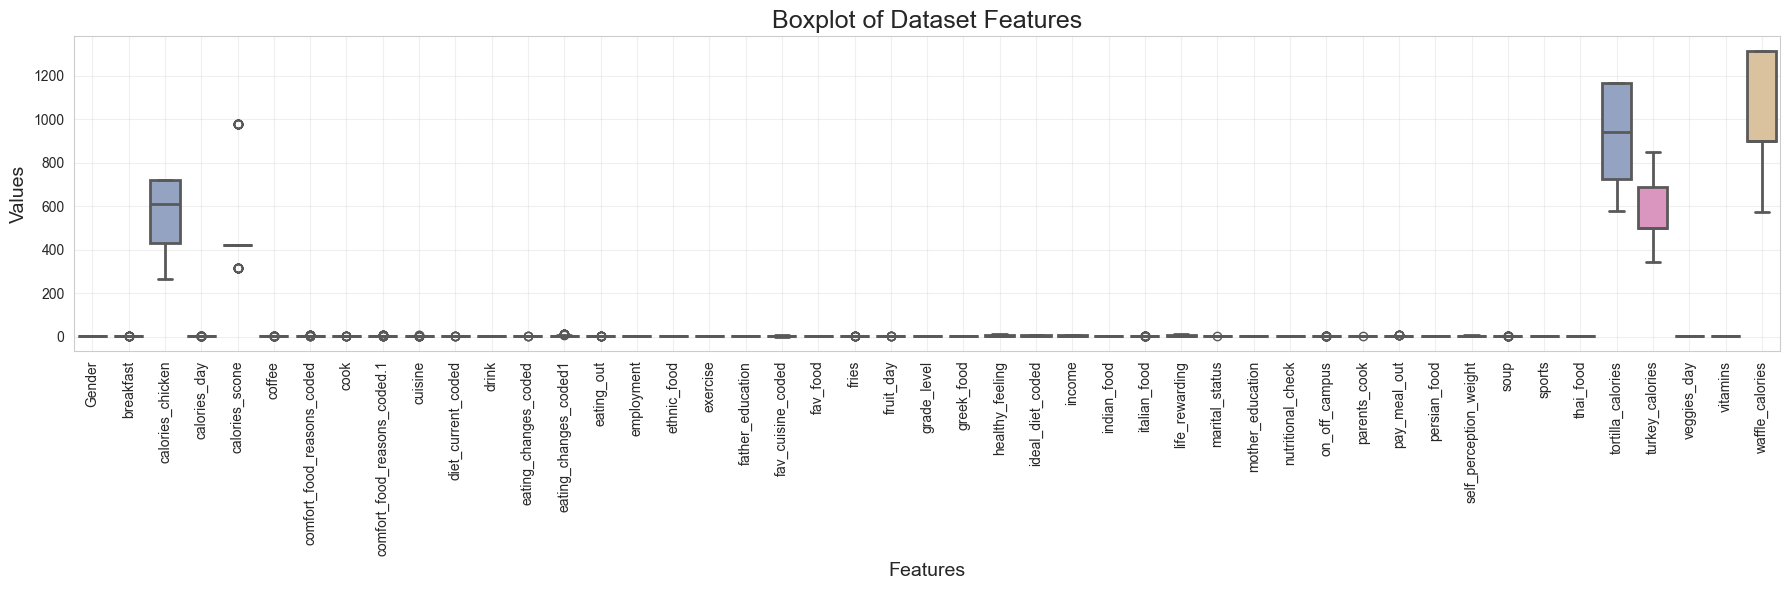

In [84]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))

numeric_df = df.select_dtypes(include=np.number)
sns.boxplot(
    data=numeric_df,
    palette="Set2",
    linewidth=2
)

plt.xlabel("Features", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.xticks(rotation=90)
plt.title("Boxplot of Dataset Features", fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

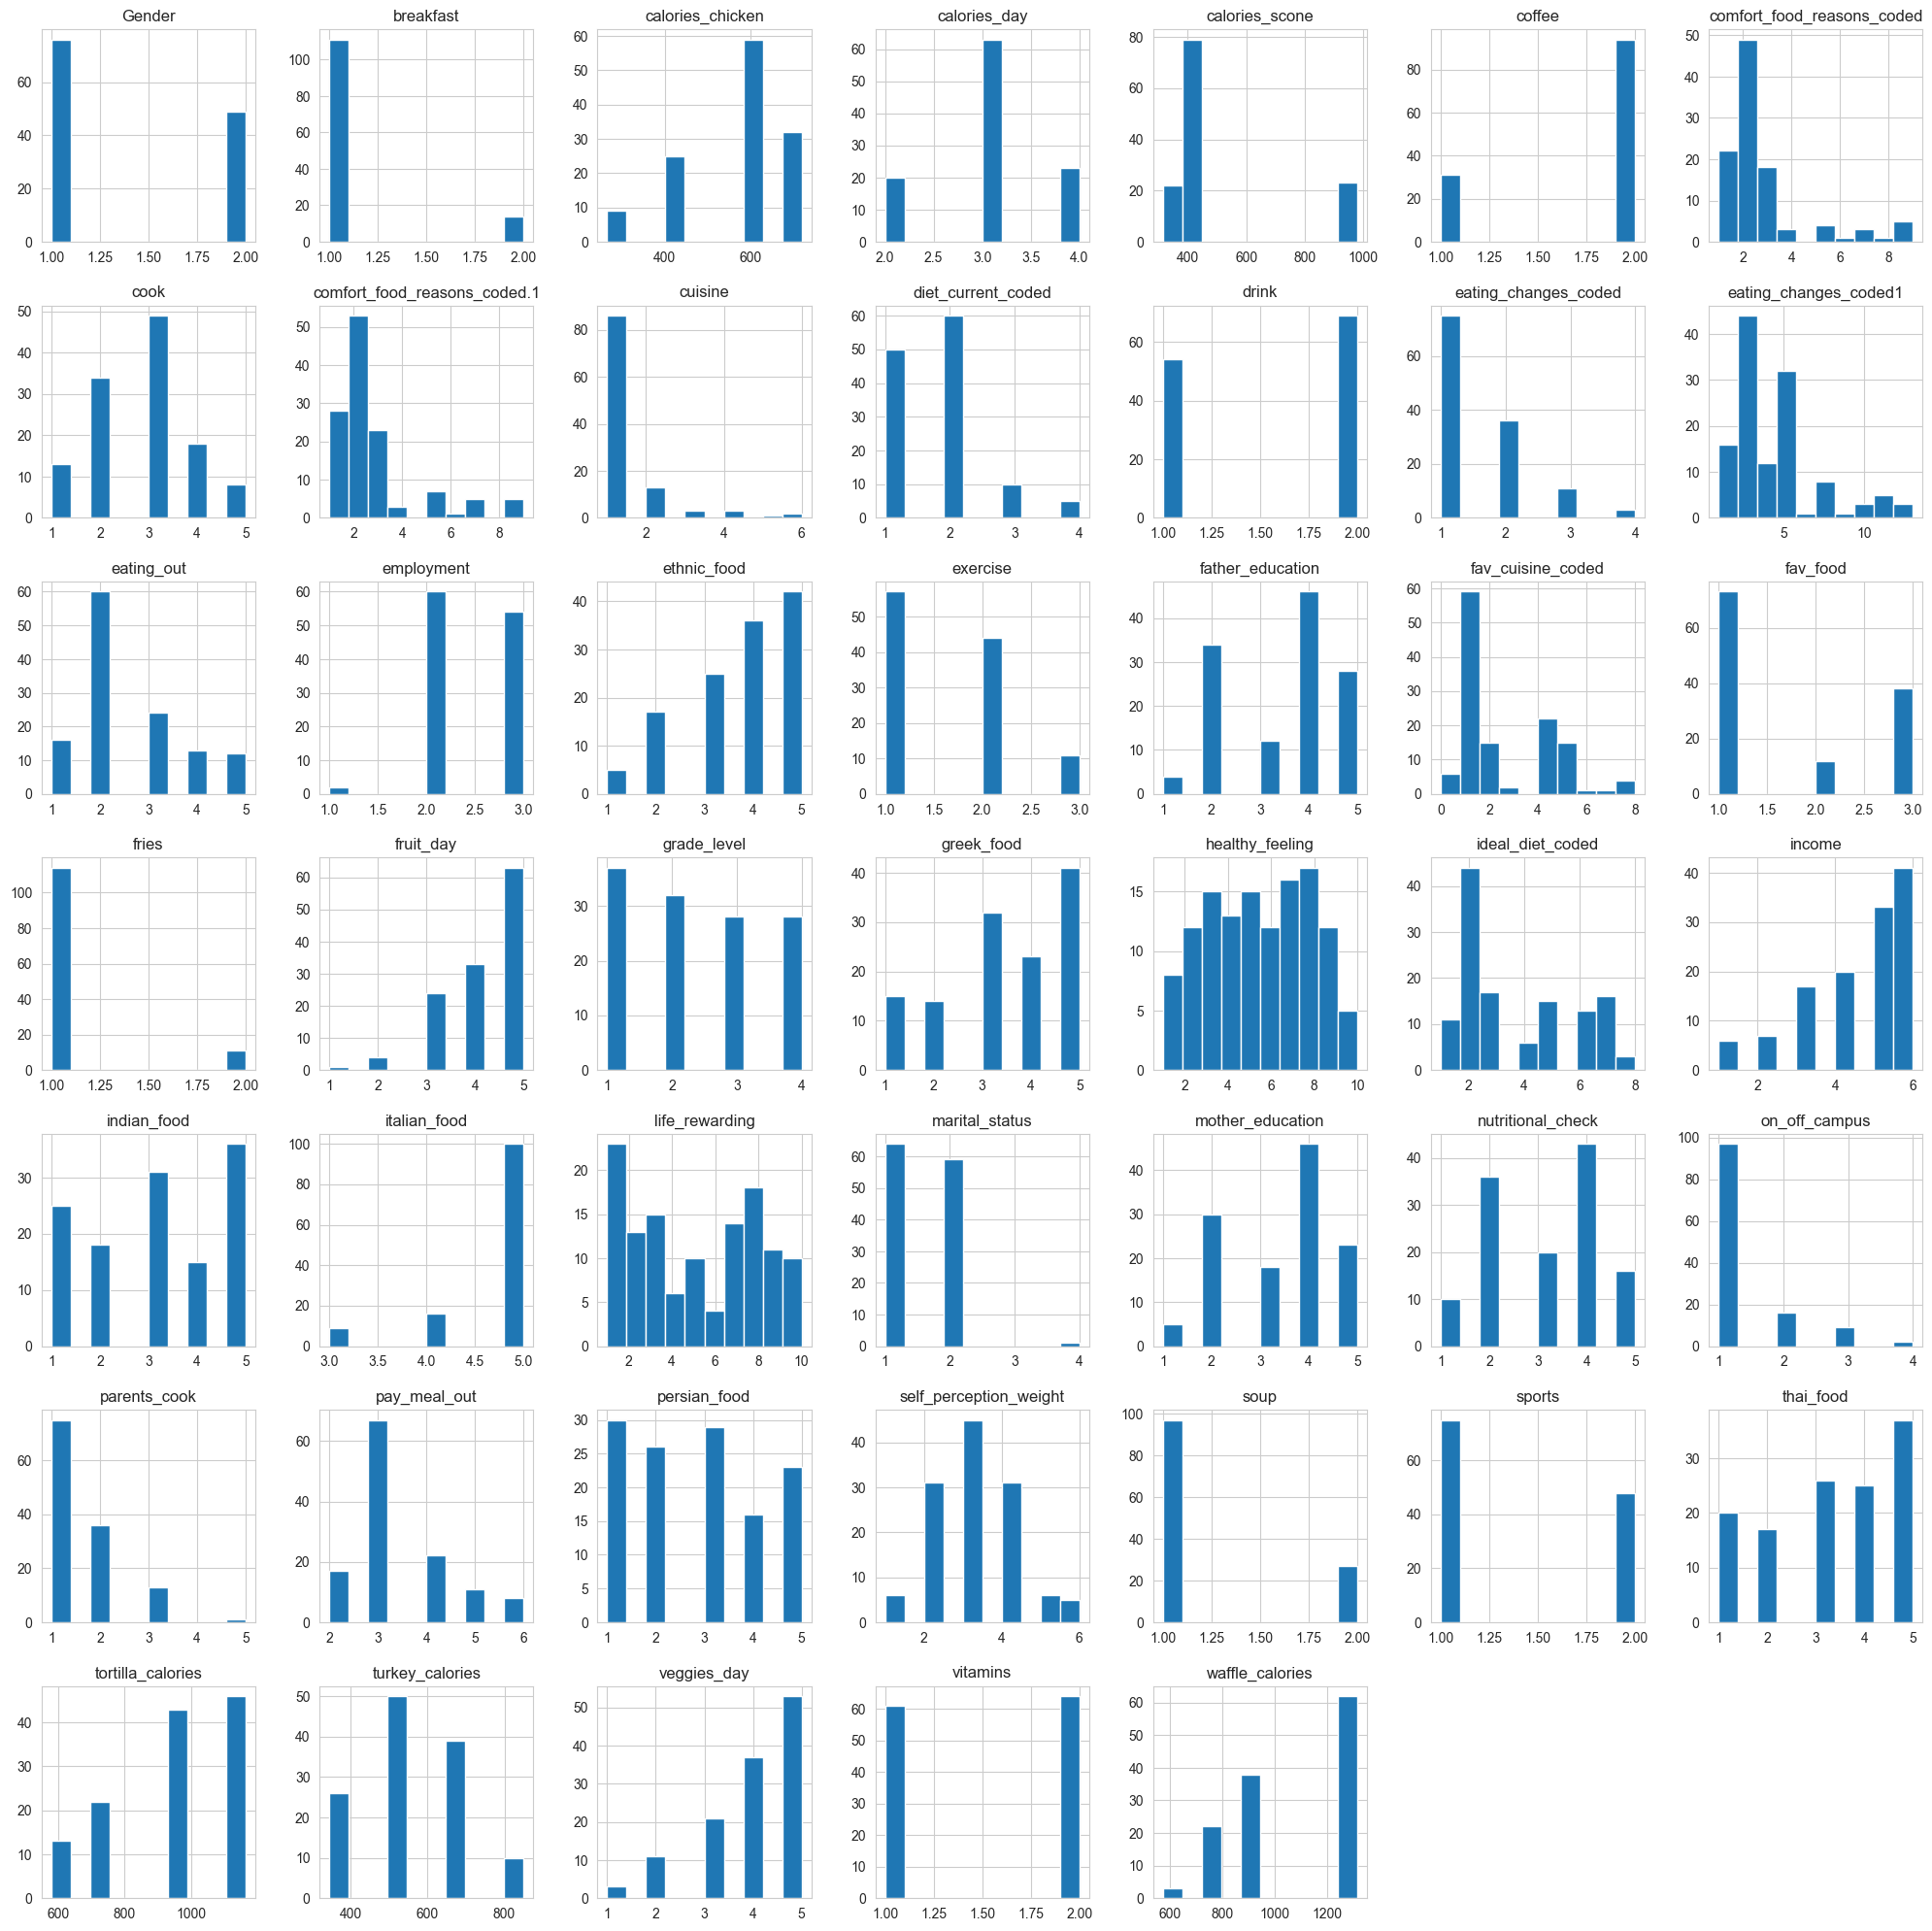

In [85]:
df.hist(figsize=(25, 25)) #histogram
plt.show()

**Preprocessing**

In [86]:
#Remove Text Columns
text_columns = [ 
    'comfort_food',
    'comfort_food_reasons',
    'diet_current',
    'eating_changes',
    'healthy_meal',
    'ideal_diet',
    'food_childhood',
    'meals_dinner_friend'
]
for col in text_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [87]:
for col in df.columns: #Nan Control
    
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [88]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

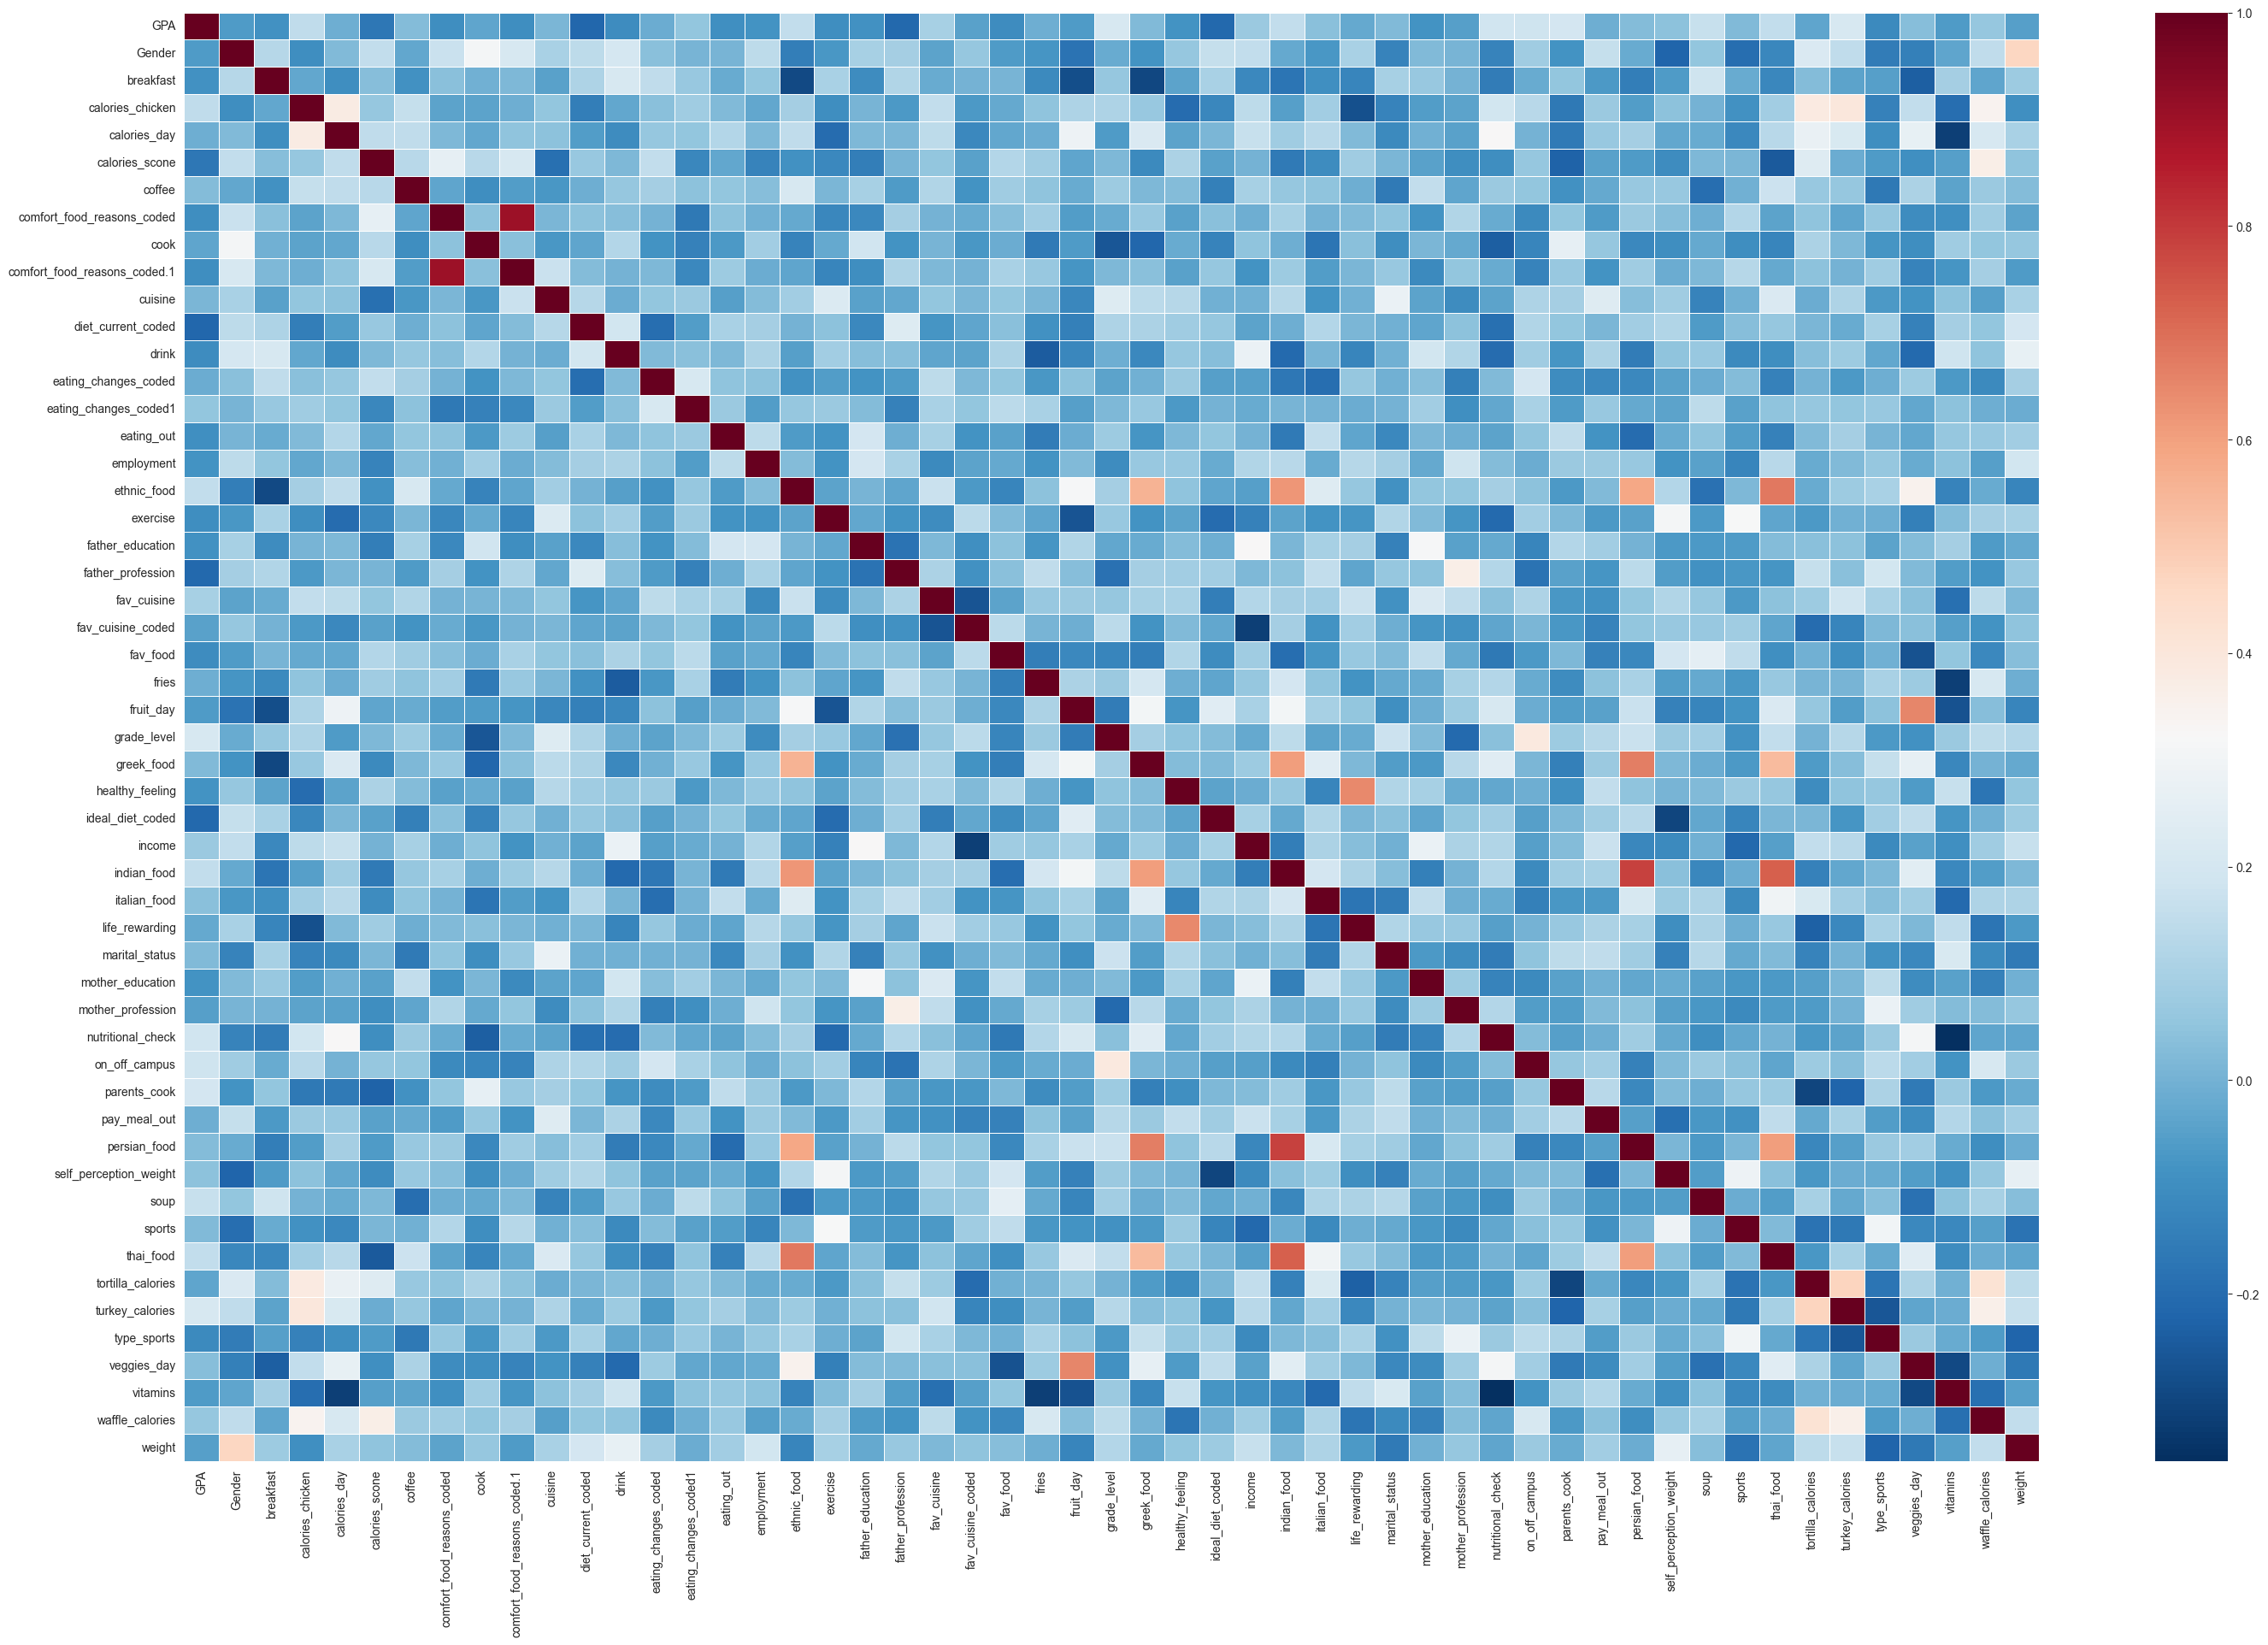

In [89]:
#df.corr()

fig, ax = plt.subplots(figsize = (35, 22)) #Show correlation
ax = sns.heatmap(df.corr(),cmap='RdBu_r',cbar=True,annot=False,linewidths=0.5,ax=ax)
plt.show()

**Split Feature & Target**

In [90]:
TARGET_COLUMN = "sports"
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

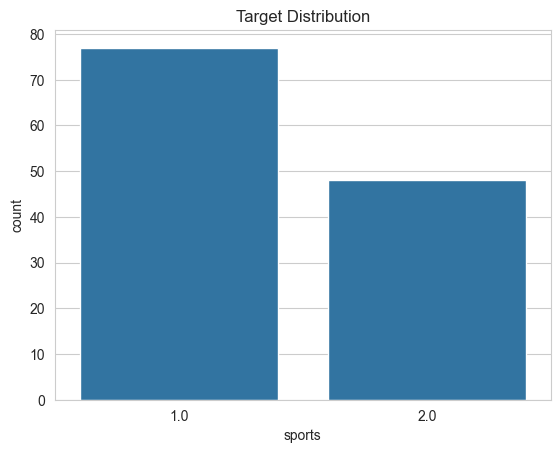

In [91]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

**Train & Test Split**

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Random Forest**

**Creating & Training Random Forest Model**

In [93]:
rf = RandomForestClassifier(n_estimators=200 ,max_depth=10, random_state=42, class_weight='balanced', criterion='entropy',
                            min_samples_split=2)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [94]:
from sklearn.model_selection import GridSearchCV

p = {
    'n_estimators': [50,100,200],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5,10],
    'criterion': ['gini', 'entropy']
}

g = GridSearchCV(
    rf,
    p,
    cv=5,
    n_jobs=-1
)

g.fit(X_train, y_train)
print(g.best_params_)
print(g.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
0.8299999999999998


**Metrics**

In [95]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nAccuracy: {rf_accuracy * 100:.2f}%")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Accuracy: 72.00%
Precision: 0.7190
Recall: 0.7200
F1 Score: 0.7080

Confusion Matrix:
[[13  2]
 [ 5  5]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.72      0.87      0.79        15
         2.0       0.71      0.50      0.59        10

    accuracy                           0.72        25
   macro avg       0.72      0.68      0.69        25
weighted avg       0.72      0.72      0.71        25



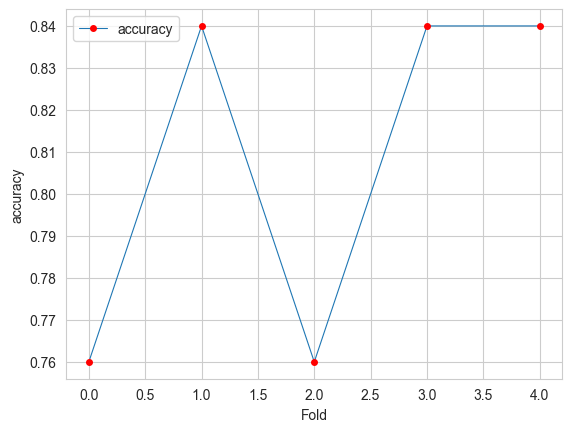

In [96]:
scores = cross_val_score(rf, X, y,cv=5, scoring='accuracy')

plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
plt.xlabel('Fold')
plt.ylabel('accuracy')
plt.legend()
plt.show()

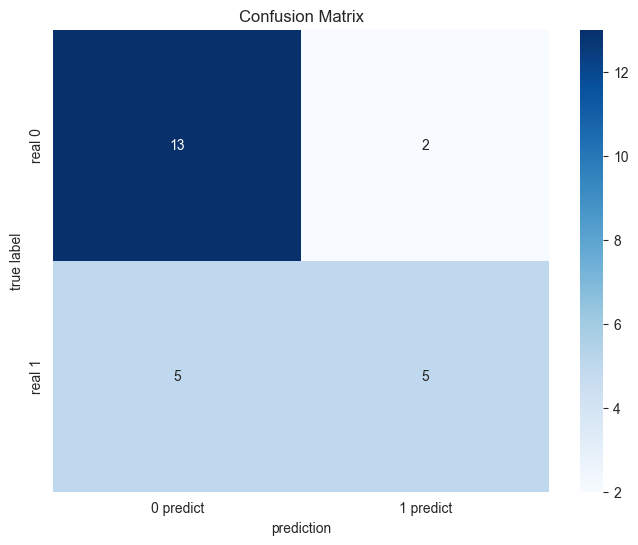

In [97]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['0 predict', '1 predict'], yticklabels=['real 0', 'real 1'])
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

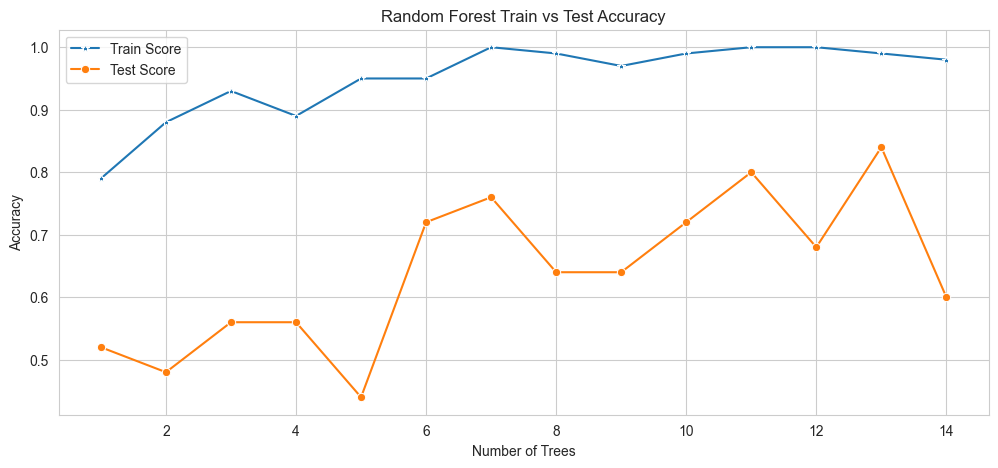

In [98]:
train_scores = []
test_scores = []

for i in range(1,15):
    m = RandomForestClassifier(i)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))
plt.figure(figsize=(12,5))

# Pass keyword arguments x= and y=
sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Train vs Test Accuracy")
plt.legend()
plt.show()

## **KNN**

**Scaling**

In [99]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Creating & Training KNN Model**

In [100]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [101]:
from sklearn.model_selection import GridSearchCV

p = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

g = GridSearchCV(
    knn,
    p,
    cv=5,
    n_jobs=-1
)

g.fit(X_train_scaled, y_train)
print(g.best_params_)
print(g.best_score_)

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
0.72


**Metrics**

In [102]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print(f"\nAccuracy: {knn_accuracy * 100:.2f}%")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1 Score: {knn_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


Accuracy: 60.00%
Precision: 0.5714
Recall: 0.6000
F1 Score: 0.5476

Confusion Matrix:
[[13  2]
 [ 8  2]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.62      0.87      0.72        15
         2.0       0.50      0.20      0.29        10

    accuracy                           0.60        25
   macro avg       0.56      0.53      0.50        25
weighted avg       0.57      0.60      0.55        25



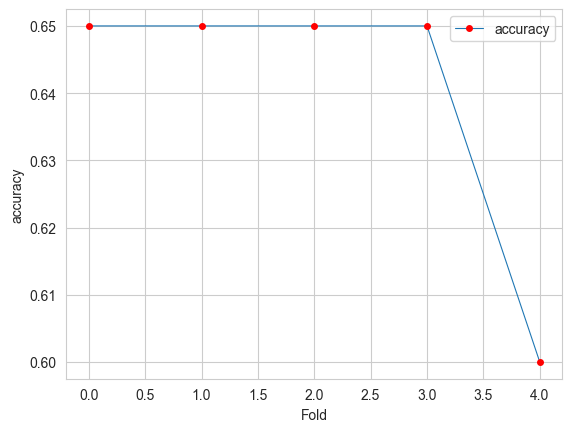

In [103]:
scores = cross_val_score(knn, X_train_scaled, y_train ,cv=5, scoring='accuracy')

plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
plt.xlabel('Fold')
plt.ylabel('accuracy')
plt.legend()
plt.show()

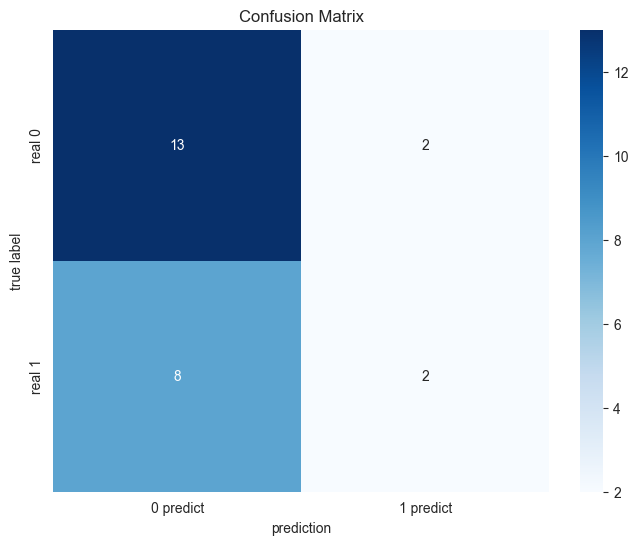

In [104]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['0 predict', '1 predict'], yticklabels=['real 0', 'real 1'])
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

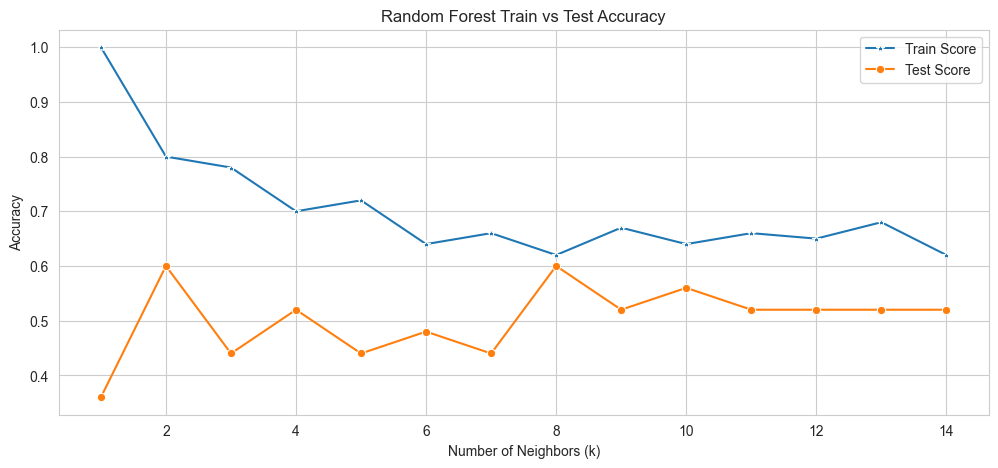

In [105]:
train_scores = []
test_scores = []

for i in range(1,15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))
plt.figure(figsize=(12,5))

# Pass keyword arguments x= and y=
sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Random Forest Train vs Test Accuracy")
plt.legend()
plt.show()

## **SVM**

**Scaling**

In [106]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Creating & Training SVM Model**

In [107]:
svm = SVC(kernel='poly', degree=2, gamma='auto')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [108]:
from sklearn.model_selection import GridSearchCV

p={'kernel':['linear','poly','rbf'],
   'gamma':['scale','auto'],
   'degree':[1,2,4,5,6]

}
g = GridSearchCV(svm, p, n_jobs=-1, cv=5)
g.fit(X, y)
print(g.best_params_)

{'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}


**Metrics**

In [109]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\nAccuracy: {svm_accuracy * 100:.2f}%")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1 Score: {svm_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Accuracy: 60.00%
Precision: 0.5714
Recall: 0.6000
F1 Score: 0.5476

Confusion Matrix:
[[13  2]
 [ 8  2]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.62      0.87      0.72        15
         2.0       0.50      0.20      0.29        10

    accuracy                           0.60        25
   macro avg       0.56      0.53      0.50        25
weighted avg       0.57      0.60      0.55        25



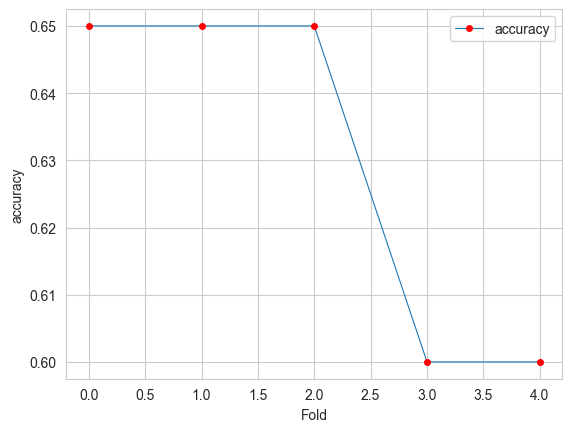

In [110]:
scores = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='accuracy')

plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
plt.xlabel('Fold')
plt.ylabel('accuracy')
plt.legend()
plt.show()

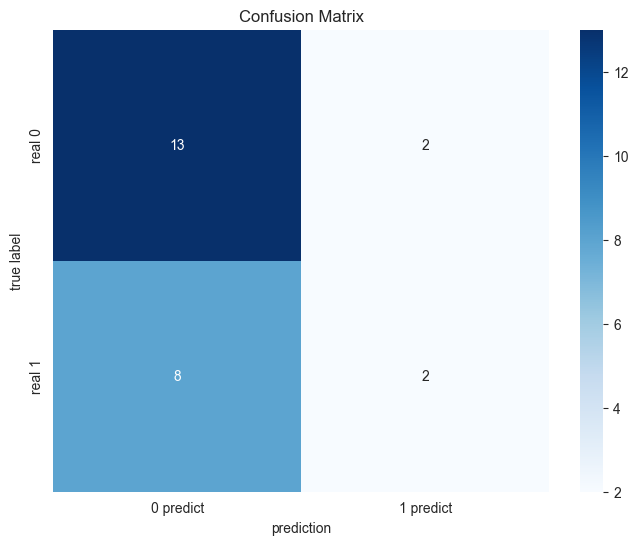

In [111]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['0 predict', '1 predict'], yticklabels=['real 0', 'real 1'])
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

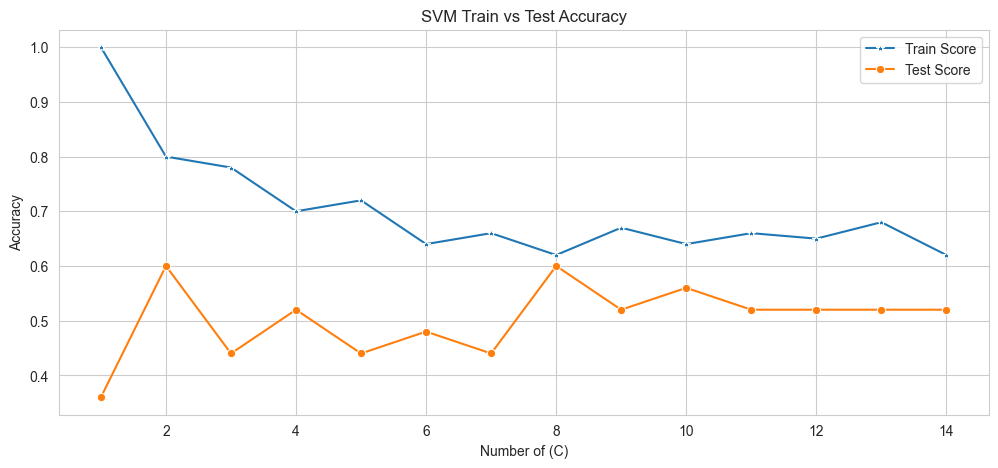

In [112]:
train_scores = []
test_scores = []

for i in range(1,15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))
plt.figure(figsize=(12,5))

# Pass keyword arguments x= and y=
sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("Number of (C)")
plt.ylabel("Accuracy")
plt.title("SVM Train vs Test Accuracy")
plt.legend()
plt.show()

# **Ploting Results**

In [113]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "KNN",
        "SVM"
    ],

    "Accuracy": [
        rf_accuracy * 100,
        knn_accuracy * 100,
        svm_accuracy * 100
    ]
})

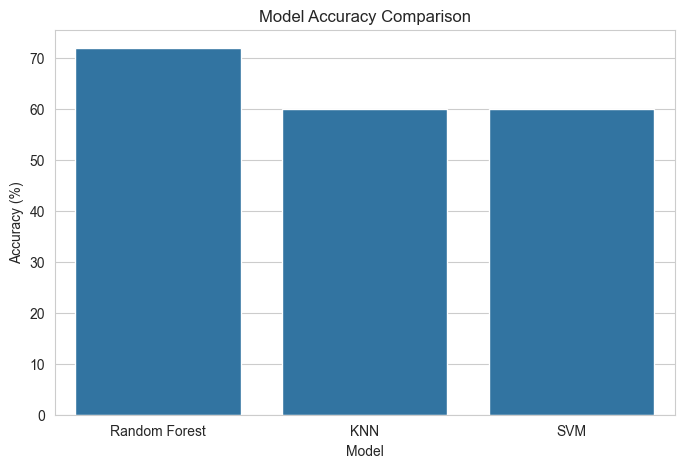

In [114]:
# ACCURACY PLOT
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

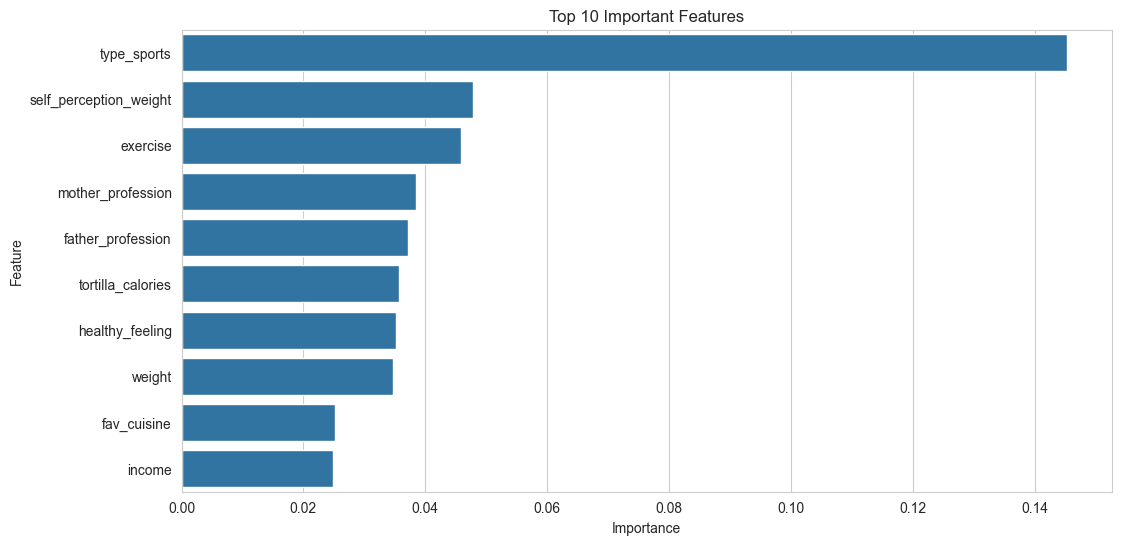

In [115]:
# FEATURE IMPORTANCE PLOT

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# **Conclusion: Best Algorithm is ...**

In [116]:
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print(f"KNN Accuracy: {knn_accuracy*100:.2f}%")
print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")
print("\nBest Model: Random Forest")

Random Forest Accuracy: 72.00%
KNN Accuracy: 60.00%
SVM Accuracy: 60.00%

Best Model: Random Forest
